In [19]:
import pickle as pkl
import numpy as np

from pathlib import Path
from scipy.interpolate import interp1d
import src.statistics.spline as spline

In [ ]:
sc = [.3, 3]  # scale cut in Mpc/h
root = Path(f'/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/splines_{sc[0]}_{sc[1]}_vF/')
temp = Path(f'/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/distributions/{sc[0]}_{sc[1]}/nz_samples_{sc[0]}_{sc[1]}_vF.fits')
output = Path(f'/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/distributions/{sc[0]}_{sc[1]}/nz_samples_{sc[0]}_{sc[1]}_vF.sacc')
prefix_spl = 'spl_npz_bs_bp_mag_'

splines_dict = {tomo : spline.BayesianBSpline.from_saved_model(f'{root}/{prefix_spl}{tomo}') for tomo in [1,2,3,4]} 
metadata = {tomo : pkl.load(open(f'{root}/{prefix_spl}{tomo}_meta.pkl', 'rb')) for tomo in [1,2,3,4]}
bounds = {
    '1' : (0, 0.8),
    '2' : (0.3, 1.3),
    '3' : (0.3, 2.1),
    '4' : (0.7, 2.1)
}

PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_1.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_1_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_2.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_2_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/splines_0.3_3_vF/spl_npz_bs_bp_mag_3.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/splines_0.3_3_vF/spl_npz_bs_bp_ma

In [27]:
tomo_samples = {}
z_eval_full = np.linspace(0, 3, 1001)
## take the midpoints of z_eval_full
z_eval_full = 0.5 * (z_eval_full[1:] + z_eval_full[:-1])
for tomo in range(1, 5):
    spl = splines_dict[tomo]

    mask = (z_eval_full > spl.zv.min()) & (z_eval_full < spl.zv.max())

    z_eval = z_eval_full[mask]
    basis_eval = spl._create_evaluation_basis(z_eval)
    coeffs_samples = spl.coeffs_samples
    if np.any(coeffs_samples < 0):
        print(f'Warning: negative coeffs in tomo {tomo}')
    amplitude_samples = spl.amplitude_samples
    if np.any(amplitude_samples < 0):
        print(f'Warning: negative amplitude in tomo {tomo}')
    
    nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]

    interp_func = interp1d(z_eval, nz_samples_full, axis=1, bounds_error=False, fill_value=0)
    nz_samples = interp_func(z_eval_full)
    complete_nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval_full) for nzs in nz_samples])

    tomo_samples[tomo] = complete_nz_samples

Text(0, 0.5, 'n(z)')

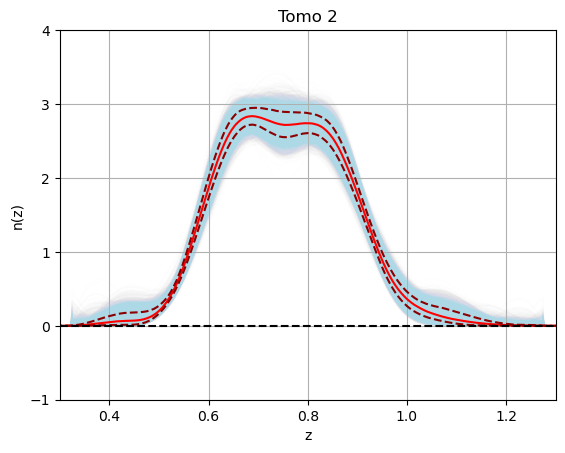

In [31]:
import matplotlib.pyplot as plt
tomo = 2
complete_nz_samples = tomo_samples[tomo]
plt.plot(z_eval_full, complete_nz_samples.T, color='lightblue', alpha=0.004)
plt.plot(z_eval_full, np.median(complete_nz_samples, axis=0), color='red')
plt.plot(z_eval_full, np.percentile(complete_nz_samples, 16, axis=0), color='darkred', ls='--')
plt.plot(z_eval_full, np.percentile(complete_nz_samples, 84, axis=0), color='darkred', ls='--')
plt.title(f'Tomo {tomo}')
plt.axhline(0, color='k', ls='--')
plt.ylim(-1, 4)
plt.xlim(bounds[str(tomo)])
plt.grid()
plt.xlabel('z')
plt.ylabel('n(z)')

In [32]:
from astropy.table import Table
from astropy.io import fits
import numpy as np

data_set = 'bs_bp_mag_vF'
n_reals = tomo_samples[1].shape[0]
n_tomo_bins = 4  

hdu_list = fits.HDUList()
hdu_list.append(fits.PrimaryHDU())

dz = z_eval_full[1] - z_eval_full[0]
z_low = z_eval_full - dz/2
z_high = z_eval_full + dz/2

for i_real in range(n_reals):
    tab = Table()
    
    tab['Z_LOW'] = z_low
    tab['Z_MID'] = z_eval_full  
    tab['Z_HIGH'] = z_high

    for tomo in range(1, n_tomo_bins + 1):
        sample_z = tomo_samples[tomo][i_real, :].copy()
        # renormalize for good measure, the samples should already be normalized
        norm = np.trapezoid(sample_z, z_eval_full)
        if norm > 0:
            sample_z = sample_z / norm
            
        tab[f'BIN{tomo}'] = sample_z
    extname = f'nz_{data_set}_realisation_{i_real}'
    hdu = fits.BinTableHDU(tab)
    # force lowercase extension name
    hdu.header['EXTNAME'] = extname.lower()
    
    hdu_list.append(hdu)

hdu_list.writeto(temp, overwrite=True)

In [33]:
from astropy.table import Table
Table.read(temp, hdu=1)

Z_LOW,Z_MID,Z_HIGH,BIN1,BIN2,BIN3,BIN4
float64,float64,float64,float64,float64,float64,float64
-2.168404344971009e-19,0.0015,0.003,0.0,0.0,0.0,0.0
0.003,0.0045000000000000005,0.006000000000000001,0.0,0.0,0.0,0.0
0.006,0.007500000000000001,0.009000000000000001,0.0,0.0,0.0,0.0
0.009000000000000001,0.0105,0.012,0.0,0.0,0.0,0.0
0.012,0.0135,0.015,0.0,0.0,0.0,0.0
0.015000000000000001,0.0165,0.018000000000000002,0.0,0.0,0.0,0.0
0.018000000000000002,0.019500000000000003,0.021000000000000005,0.0,0.0,0.0,0.0
0.020999999999999998,0.0225,0.024,0.0,0.0,0.0,0.0
0.024,0.025500000000000002,0.027000000000000003,2.851257562449474e-05,0.0,0.0,0.0


/global/cfs/projectdirs/desi/users/jchdj/conda/envs/pymc-env/lib/python3.13/site-packages/sacc/sacc.py:935: UserWarning: The FITS format without the 'sacc_ordering' column is deprecated. Assuming data rows are in the correct order as it was before version 1.0.
  warnings.warn(


Added 6400 extensions to SACC file /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/results/distributions/0.3_3/nz_samples_0.3_3_vF.sacc


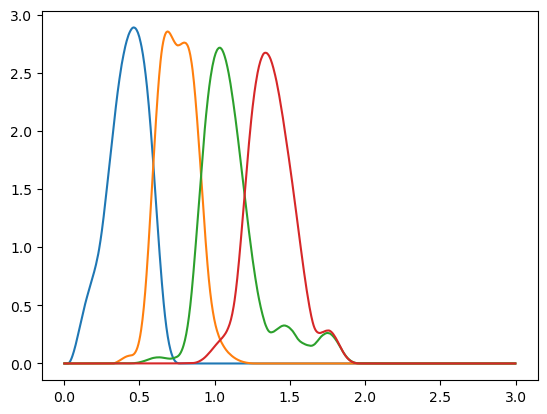

In [34]:
import sacc
add_ext = True

# Load the SACC file and update the tracers
sacc_file = '/global/cfs/projectdirs/desi/users/jchdj/software/cosmosis-standard-library/likelihood/hsc_cosmic_shear/hsc_y3_fourier_shear.sacc'
file = sacc.Sacc.load_fits(sacc_file)

with fits.open(temp) as hdul:
    for tomo in range(1, 5):
        sample = np.median(tomo_samples[tomo], axis=0)
        sample /= np.trapezoid(sample, z_eval_full)
        file.tracers[f'wl_{tomo-1}'].nz = sample
        file.tracers[f'wl_{tomo-1}'].z = z_eval_full
        plt.plot(z_eval_full, file.tracers[f'wl_{tomo-1}'].nz, label=f'Tomo {tomo}')

sacc.Sacc.save_fits(file, output, overwrite=True)

if add_ext:
    with fits.open(output, mode='update') as sacc_hdul:
        with fits.open(temp) as samples_hdul:
            # Add all extensions except the primary HDU
            for ext in samples_hdul[1:]:
                sacc_hdul.append(ext.copy())

    print(f"Added {len(samples_hdul)-1} extensions to SACC file {output}")

In [68]:
with fits.open(sacc_file) as sacc_hdul:
    print(sacc_hdul.info())
print(sacc.Sacc.load_fits(output))

Filename: /global/cfs/projectdirs/desi/users/jchdj/software/cosmosis-standard-library/likelihood/hsc_cosmic_shear/hsc_y3_fourier_shear_corrected_nz.sacc
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  2  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  3  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  4  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  5  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  6  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  7  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  8  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
  9  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17D]   
 10  window:Bandpower    1 BinTableHDU     17   15274R x 2C   [D, 17